In [ ]:
                               BREAST CANCER PREDICTOR

In [2]:
# STEP 1: Loading of Datasets

from sklearn.datasets import load_breast_cancer


#Load Breast cancer dataset
data = load_breast_cancer()

print ("loaded successfully")

loaded successfully


Shape of dataset (569, 31)
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000       

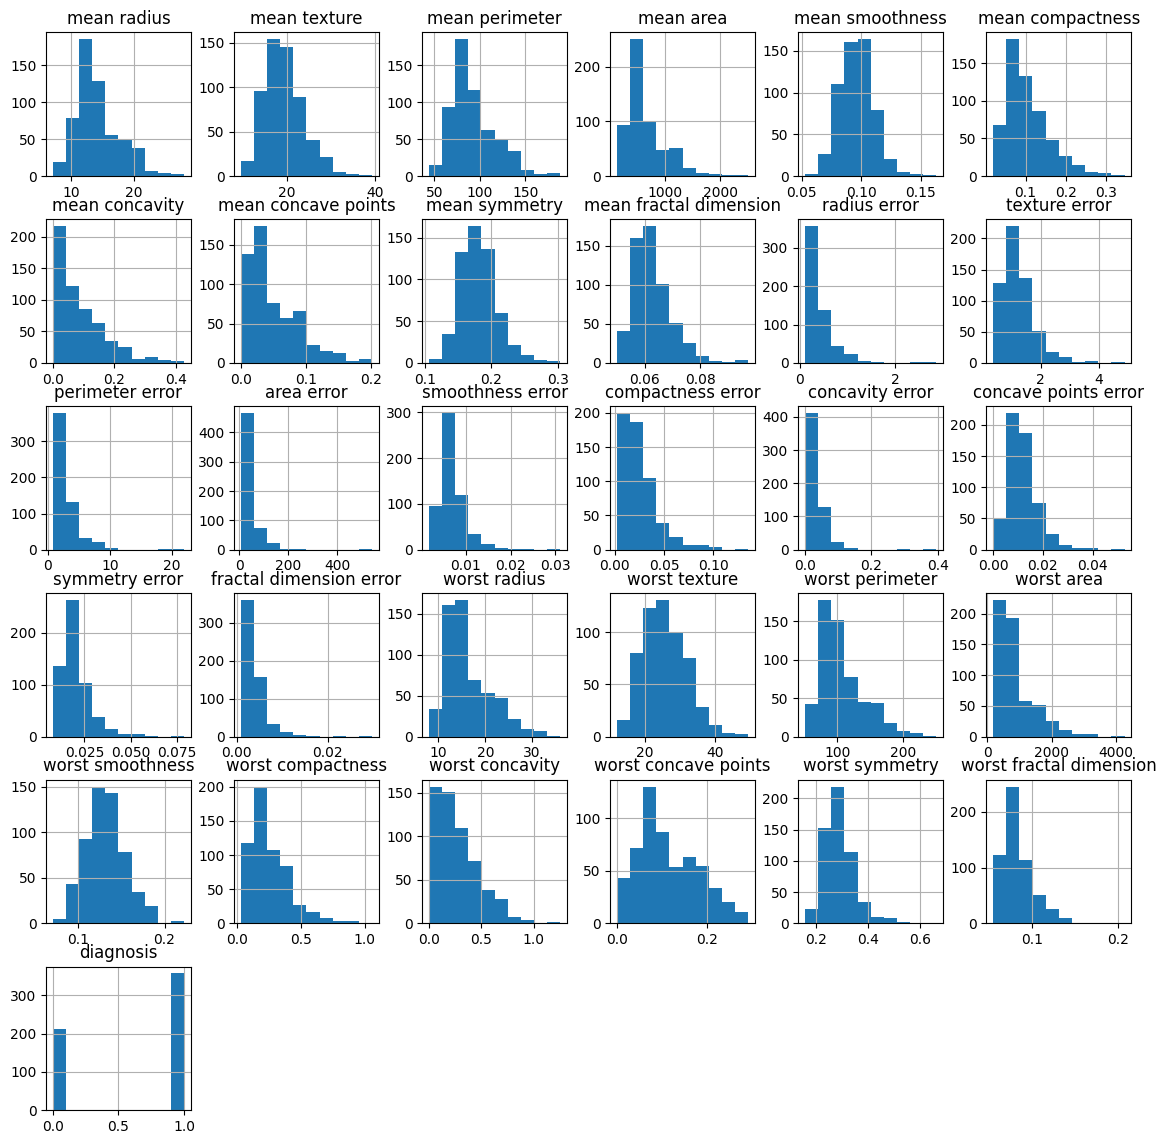

In [8]:
# STEP 2a : Turn it into a tabular form (Dataframe)/ Data Exploration

import pandas as pd
import numpy as np

df= pd.DataFrame(data.data, columns=data.feature_names)
df["diagnosis"]= data.target

print("Shape of dataset", df.shape)

# STEP 2b:

print(df.describe())
import matplotlib.pyplot as plt
df.hist(figsize=(14,14))
plt.show()

In [10]:
# STEP 2c: Full information of loaded data

print(df.info())

df=pd.DataFrame(data.data, columns=data.feature_names)
df["diagnosis"]= data.target

df["diagnosis"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,count
diagnosis,
1,357
0,212


In [12]:
# STEP 3a: Clean and Prepare the Data

print(df.isnull().sum())

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df[data.feature_names]= scaler.fit_transform(df[data.feature_names])

print("Data cleaned!")

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
dtype: int64
Data cleaned!


In [13]:
# STEP 3b: Generation of x & y variables for Model training and testing

x=df.drop ("diagnosis", axis=1) # everything except answers/diagnosis
y=df["diagnosis"]

print(x.shape)
print(y.shape)

(569, 30)
(569,)


In [14]:
# STEP 4: Split of Datasets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.3, random_state=42)

print("training patients:", x_train.shape[0])
print("testing patients:", x_test.shape[0])

training patients: 398
testing patients: 171


In [15]:
#STEP 5: Model Training

from sklearn.linear_model import LogisticRegression

model= LogisticRegression(max_iter=5000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=5000)

In [16]:
# STEP 6: Making Predictions/Model testing

y_pred= model.predict(x_test)

print("Model's guesses:", y_pred [:20])
print("Actual diagnosis:", y_test [:20].values)

Model's guesses: [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0]
Actual diagnosis: [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0]


In [17]:
# STEP 7: Checking Accuracy
from sklearn.metrics import accuracy_score
Accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model: {Accuracy:.2%}")

Accuracy of the model: 98.25%


In [18]:
# STEP 8a: Confusion matrix

from sklearn.metrics import confusion_matrix

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))



Confusion matrix:
[[ 62   1]
 [  2 106]]


Confusion matrix:
[[ 62   1]
 [  2 106]]


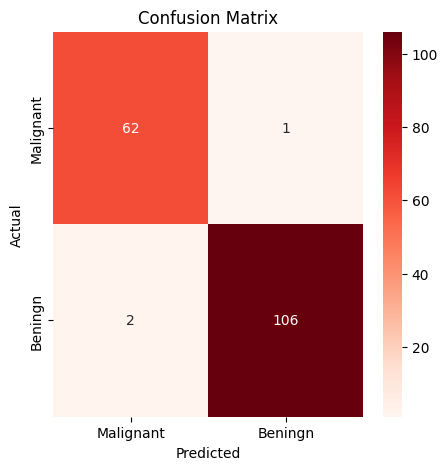

In [19]:
# STEP 8b : Data Visualization/Correlation Heat Map

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

CM= confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(CM,annot=True,fmt="d",cmap="Reds",
            xticklabels=["Malignant","Beningn"],
            yticklabels=["Malignant","Beningn"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

worst texture             -1.323063
radius error              -1.207227
worst symmetry            -1.205759
mean concave points       -1.094419
worst concavity           -0.974141
area error                -0.881542
worst concave points      -0.835418
worst radius              -0.806112
worst area                -0.772227
mean concavity            -0.769889
perimeter error           -0.565605
worst perimeter           -0.533924
worst smoothness          -0.508286
concave points error      -0.464623
mean area                 -0.424750
mean texture              -0.368886
mean radius               -0.367670
mean perimeter            -0.323265
mean smoothness           -0.184647
smoothness error          -0.171874
worst fractal dimension   -0.115292
concavity error           -0.107181
worst compactness          0.100956
mean fractal dimension     0.142817
texture error              0.169539
mean symmetry              0.240961
symmetry error             0.514638
mean compactness           0

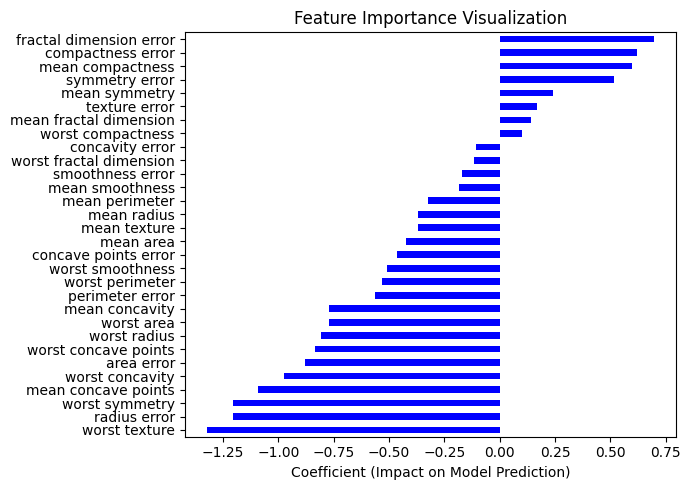

In [20]:
# STEP 8c : Which feature influenced/affect the Model Prediction most?

import pandas as pd
import matplotlib.pyplot as plt

MIF = pd.Series(model.coef_[0], index=x.columns)
MIF_sorted = MIF.sort_values(ascending=True)
print(MIF_sorted)

plt.figure (figsize= (7,5))
MIF_sorted.plot(kind= "barh", color="blue")
plt.title("Feature Importance Visualization")
plt.xlabel("Coefficient (Impact on Model Prediction)")
plt.tight_layout()
plt.show()

In [21]:
# STEP 9: Full Evaluation of Generated Model

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred,
                            target_names=["Malignant", "Beningn"]))

              precision    recall  f1-score   support

   Malignant       0.97      0.98      0.98        63
     Beningn       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [22]:
# STEP 10: Train 2 Models and Comparison of Results

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=500, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "F1 Score": f1_score(y_test, y_pred, average="macro")
    }

results_df = pd.DataFrame(results).T.round(2)
results_df

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.98,0.98,0.98,0.98
Random Forest,0.97,0.97,0.96,0.97


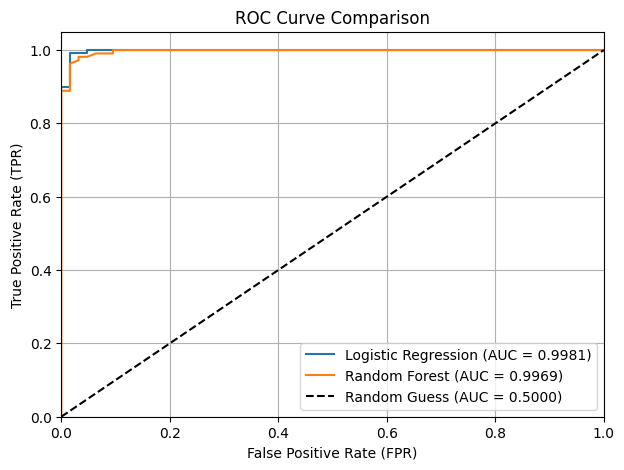

In [26]:
# STEP 11: Stability checking of Generated Models by ROC/AUC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 5))

# Loop through each model and plot its ROC Curve
for name, model in models.items():
    # Get prediction probabilities for the positive class (diagnosis = 1)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(x_test)[:, 1]
    else:
        # Fallback for models without predict_proba using decision_function
        y_probs = model.decision_function(x_test)

    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

# Plot the baseline (random guess)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.5000)")

# Chart formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [31]:
# STEP 12: Save the Best Performing Model (Logistic Regression) and Scaler

import joblib

# Save the best performing model
best_model = models['Logistic Regression']
joblib.dump(best_model, 'model.joblib')

print("Model saved as 'model.joblib'successfully")
print("Accuracy on training data:", best_model.score(x_train, y_train))
print("Accuracy on testing data:", best_model.score(x_test, y_test))

# Save the Scaler
joblib.dump(scaler, 'scaler.joblib')
print("Scaler saved successfully")

Model saved as 'model.joblib'successfully
Accuracy on training data: 0.9874371859296482
Accuracy on testing data: 0.9824561403508771
Scaler saved successfully


In [41]:
 # STEP 13: Load the model back and Prediction function creation and Testing
import numpy as np
import joblib

def get_prediction(worst_concavity, mean_radius, texture_error):
    # Load scaler and model
    scaler_loaded = joblib.load('scaler.joblib')
    model_loaded = joblib.load('model.joblib')

    print("Model loaded back successfully")

    # Reconstruct the 30 features expected by the scaler
    input_data = np.zeros((1, 30))
    input_data[0, 0] = mean_radius       # mean radius
    input_data[0, 11] = texture_error     # texture error
    input_data[0, 26] = worst_concavity   # worst concavity

    # Transform and predict
    scaled_data = scaler_loaded.transform(input_data)
    result = model_loaded.predict(scaled_data)[0]
    probability = model_loaded.predict_proba(scaled_data)[0]

    label = "Benign (Non-Cancerous)" if result == 1 else "Malignant (Cancerous)"
    confidence = max(probability) * 100

    return f"Prediction: {label}\nConfidence: {confidence:.2f}%"

# Test run with sample input
sample_output = get_prediction(worst_concavity=0.1, mean_radius=14.0, texture_error=1.0)
print("Prediction function created! Test runs successfully")
print(sample_output)

Model loaded back successfully
Prediction function created! Test runs successfully
Prediction: Malignant (Cancerous)
Confidence: 99.11%


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [42]:
# STEP 13: Build the app interface with gradio

import gradio as gr
import joblib
import numpy as np

# Load the scaler and model
try:
    loaded_model = joblib.load('model.joblib')
    loaded_scaler = joblib.load('scaler.joblib')
except Exception as e:
    print("Error loading model/scaler. Please ensure STEP 12a has been run:", e)

def predict_tumor(worst_concavity, mean_radius, texture_error):
    # Reconstruct the 30 features expected by scaler
    input_data = np.zeros((1, 30))
    # Map inputs to their correct indices based on data.feature_names
    input_data[0, 0] = mean_radius       # mean radius
    input_data[0, 11] = texture_error     # texture error
    input_data[0, 26] = worst_concavity   # worst concavity

    scaled_data = loaded_scaler.transform(input_data)
    prediction = loaded_model.predict(scaled_data)[0]

    if prediction == 1:
        return "Benign (non-cancerous)"
    else:
        return "Malignant (cancerous)"

# Let's create a simple input interface using 3 of our most influential features
app = gr.Interface(
    fn=predict_tumor,
    inputs=[
        gr.Number(label="Worst Concavity", value=0.1),
        gr.Number(label="Mean Radius", value=14.0),
        gr.Number(label="Texture Error", value=1.0),
    ],
    outputs=gr.Textbox(label="Results"),
    title="Breast Cancer Diagnosis Prediction App 🎗️🏥",
    description="Enter the patient's clinical measurements below to predict diagnosis (This is a learning demo, not the real medical tool)."
)

print("App built successfully! ready to deploy")

App built successfully! ready to deploy


In [43]:
# STEP 14: Deployment
app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://317f5caa1daaac713d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [81]:
!pip install -q streamlit
print("Streamlit installed successfully")

Streamlit installed successfully


In [104]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
import pandas as pd

@st.cache_resource
def load_assets():
    model = joblib.load("model.joblib")
    scaler = joblib.load("scaler.joblib")
    return model, scaler

model, scaler = load_assets()

st.set_page_config(
    page_title="Breast Tumor Diagnosis Predictor",
    page_icon="🩺",
    layout="wide"
)

st.title("Breast Tumor Diagnosis Predictor 🩺🎗️")
st.write("Enter the patient's clinical measurements below to predict whether the tumor is Benign or Malignant.")

# Let's create a simple input interface using 3 of our most influential features
worst_concavity = st.number_input("Worst Concavity", value=0.1)
mean_radius = st.number_input("Mean Radius", value=14.0)
texture_error = st.number_input("Texture Error", value=1.0)

if st.button("Predict"):
    # Map features back to the required 30 inputs expected by the scaler and model
    # Using mean values as a placeholder for the remaining features
    input_data = np.zeros((1, 30))

    # Feature index mapping from data.feature_names:
    # mean radius is index 0
    input_data[0, 0] = mean_radius
    # texture error is index 11
    input_data[0, 11] = texture_error
    # worst concavity is index 26
    input_data[0, 26] = worst_concavity

    # Scale features and predict
    scaled_data = scaler.transform(input_data)
    prediction = model.predict(scaled_data)[0]

    # Get probabilities for confidence score estimation
    probabilities = model.predict_proba(scaled_data)[0]
    confidence = max(probabilities) * 100

    st.subheader("Prediction Result:")
    if prediction == 1:
        st.success(f"**Benign (non-cancerous)**")
        st.info(f"Confidence Level: **{confidence:.2f}%**")
    else:
        st.error(f"**Malignant (cancerous)**")
        st.warning(f"Confidence Level: **{confidence:.2f}%**")

st.caption("⚠️ Disclaimer: This is a machine learning demo application for educational purposes only. It is not intended to be a real medical diagnostic tool.")

Overwriting app.py


In [ ]:
# STEP 14:

# 1. Kill any existing background processes running on port 8501
!fuser -k 8501/tcp || true

# 2. Fetch your public IP (needed as the password for LocalTunnel bypass)
!curl ipv4.icanhazip.com

# 3. Clear logs and run Streamlit in the background
with open("logs.txt", "w") as f:
    f.write("")  # Reset logs

import subprocess
import time

process = subprocess.Popen(
    ["python", "-m", "streamlit", "run", "app.py", "--server.headless", "true", "--server.port", "8501"],
    stdout=open("logs.txt", "a"),
    stderr=subprocess.STDOUT,
)

# Wait for Streamlit to initialize
time.sleep(3)

# 4. Expose the port using localtunnel
!npm install -g localtunnel
!lt --port 8501

136.70.67.0
⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 963ms
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧your url is: https://plain-clowns-decide.loca.lt


In [91]:
!ls -lh app.py *.joblib

-rw-r--r-- 1 root root 2.0K Oct  5 01:46 app.py
-rw-r--r-- 1 root root 1.9K Oct  5 00:31 model.joblib
-rw-r--r-- 1 root root 2.1K Oct  5 00:31 scaler.joblib


In [92]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".joblib") or file == "app.py":
            print(os.path.join(root, file))

/content/model.joblib
/content/app.py
/content/scaler.joblib


In [98]:
from google.colab import files

files.download("/content/app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [99]:
from google.colab import files
files.download("/content/model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [102]:
files.download("/content/scaler.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>